# Content Quality & Engagement Prediction — Part 2
### Exploratory Data Analysis, Text Feature Engineering & Target Definition

This notebook continues directly from **Part 1** (`content_quality_eda.ipynb`),
which produced the cleaned, leakage-checked `modeling_dataset.csv`
(one row per `question_id`, 37,719 rows). Here we:

1. Explore engagement and quality patterns in depth (distributions, time,
   topic, segments, content-characteristic relationships)
2. Engineer text-derived features from what the data actually supports
3. Define and justify a target variable, and check class balance
4. Engineer the final Part-2 modeling dataset (behavioral, content, user,
   category, text, and temporal features) with an explicit leakage audit

**No machine learning is trained in this notebook** — it ends with a clean,
documented modeling dataset and a recommended modeling approach.

## 0. Setup & Load Part 1 Output

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
palette = sns.color_palette("viridis", 10)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/modeling_dataset.csv", parse_dates=["created_date"])
print(f"Loaded Part 1 cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Loaded Part 1 cleaned dataset: 37,719 rows x 27 columns


,question_id,user_id,topic,word_count,word_count_bucket,created_date,created_dow,created_is_weekend,asker_country,asker_device_type,variant,asker_account_age_at_question_days,account_age_bucket,asker_prior_questions_count,asker_prior_quality_rate,num_views,num_answers,num_upvotes,upvote_rate,answer_rate,engagement_score,is_high_engagement,unique_answer_actors,unique_ask_actors,unique_upvote_actors,unique_view_actors,got_quality_answer
0,17682,1,health,51,medium,2026-06-29,Monday,False,in,mobile,control,76,established (3-12mo),0,NaN,27,1,6,0.222222,0.037037,0.224915,0,2,1,2,1,1
1,20829,1,career,94,long,2026-07-04,Saturday,True,in,mobile,control,81,established (3-12mo),1,1.0,23,0,0,0.000000,0.000000,0.128205,0,0,1,0,2,0
2,21434,1,science,27,short,2026-07-05,Sunday,True,in,mobile,control,82,established (3-12mo),2,0.5,25,1,6,0.240000,0.040000,0.212095,0,0,1,1,4,1


In [3]:
df.dtypes

question_id                                    int64
user_id                                        int64
topic                                            str
word_count                                     int64
word_count_bucket                                str
created_date                          datetime64[us]
created_dow                                      str
created_is_weekend                              bool
asker_country                                    str
asker_device_type                                str
variant                                          str
asker_account_age_at_question_days             int64
account_age_bucket                               str
asker_prior_questions_count                    int64
asker_prior_quality_rate                     float64
num_views                                      int64
num_answers                                    int64
num_upvotes                                    int64
upvote_rate                                  f

## 1. Exploratory Data Analysis

### 1.1 Content Engagement Distributions

We look at the four core engagement signals available in the data: **views**,
**upvotes**, **answers**, and the binary **quality indicator**
(`got_quality_answer`). Note: the extracts provided do **not** include a
comments field — there is no `num_comments` or comment log in any of the
four source CSVs, so comments cannot be analyzed here.

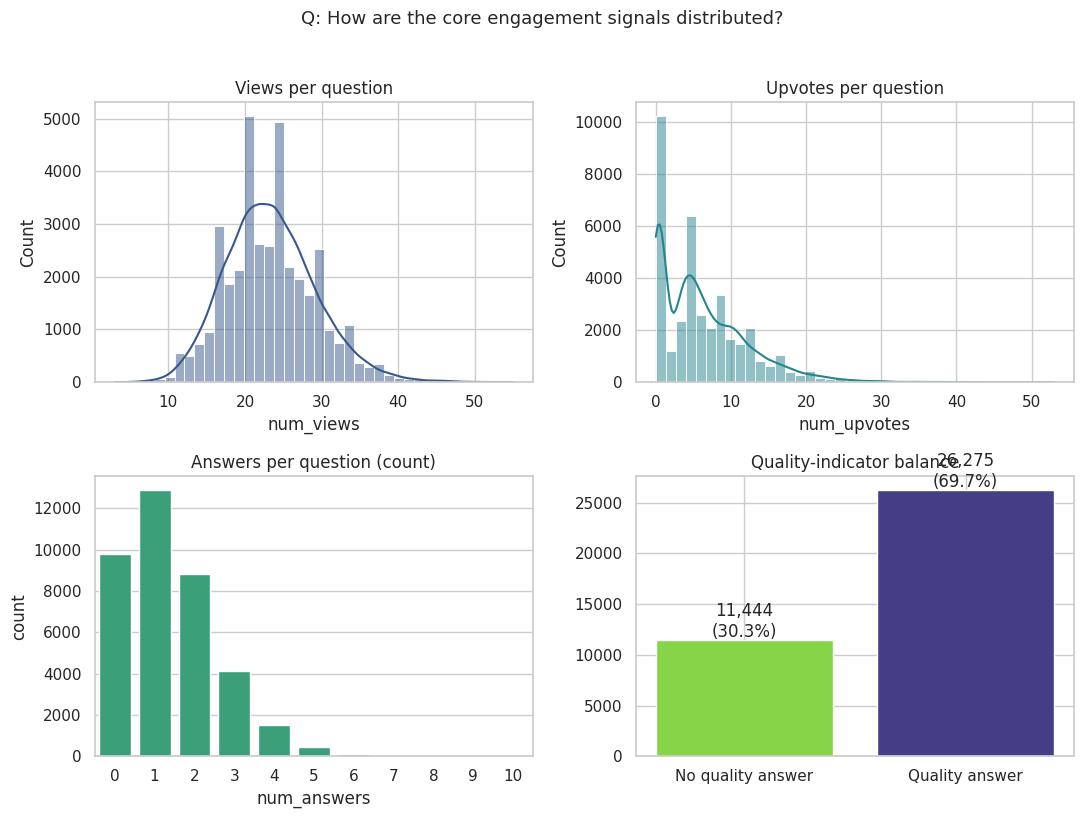

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(df.num_views, bins=40, kde=True, ax=axes[0, 0], color=palette[2])
axes[0, 0].set_title("Views per question")

sns.histplot(df.num_upvotes, bins=40, kde=True, ax=axes[0, 1], color=palette[4])
axes[0, 1].set_title("Upvotes per question")

sns.countplot(x=df.num_answers, ax=axes[1, 0], color=palette[6])
axes[1, 0].set_title("Answers per question (count)")

quality_counts = df.got_quality_answer.value_counts().sort_index()
axes[1, 1].bar(["No quality answer", "Quality answer"], quality_counts.values,
                color=[palette[8], palette[1]])
for i, v in enumerate(quality_counts.values):
    axes[1, 1].text(i, v + 300, f"{v:,}\n({v/len(df):.1%})", ha="center")
axes[1, 1].set_title("Quality-indicator balance")

plt.suptitle("Q: How are the core engagement signals distributed?", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_01_engagement_distributions.png", bbox_inches="tight")
plt.show()

**Reading:** views and upvotes are right-skewed with a long tail of
high-performing questions (consistent with the outlier check in Part 1 —
these are plausible viral questions, not errors). ~44% of questions get zero
answers, and most that do get answered receive exactly one. `got_quality_answer`
is positive for ~70% of questions — moderately imbalanced toward "quality",
not toward the rare class.

In [5]:
print("num_views  :", df.num_views.describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_dict())
print("num_upvotes:", df.num_upvotes.describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_dict())
print("num_answers:", df.num_answers.describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_dict())

num_views  : {'count': 37719.0, 'mean': 23.3, 'std': 5.9, 'min': 3.0, '50%': 23.0, '75%': 27.0, '90%': 31.0, '95%': 34.0, '99%': 39.0, 'max': 55.0}
num_upvotes: {'count': 37719.0, 'mean': 6.3, 'std': 5.8, 'min': 0.0, '50%': 5.0, '75%': 10.0, '90%': 14.0, '95%': 18.0, '99%': 24.0, 'max': 53.0}
num_answers: {'count': 37719.0, 'mean': 1.4, 'std': 1.2, 'min': 0.0, '50%': 1.0, '75%': 2.0, '90%': 3.0, '95%': 4.0, '99%': 5.0, 'max': 10.0}


### 1.2 Engagement Over Time

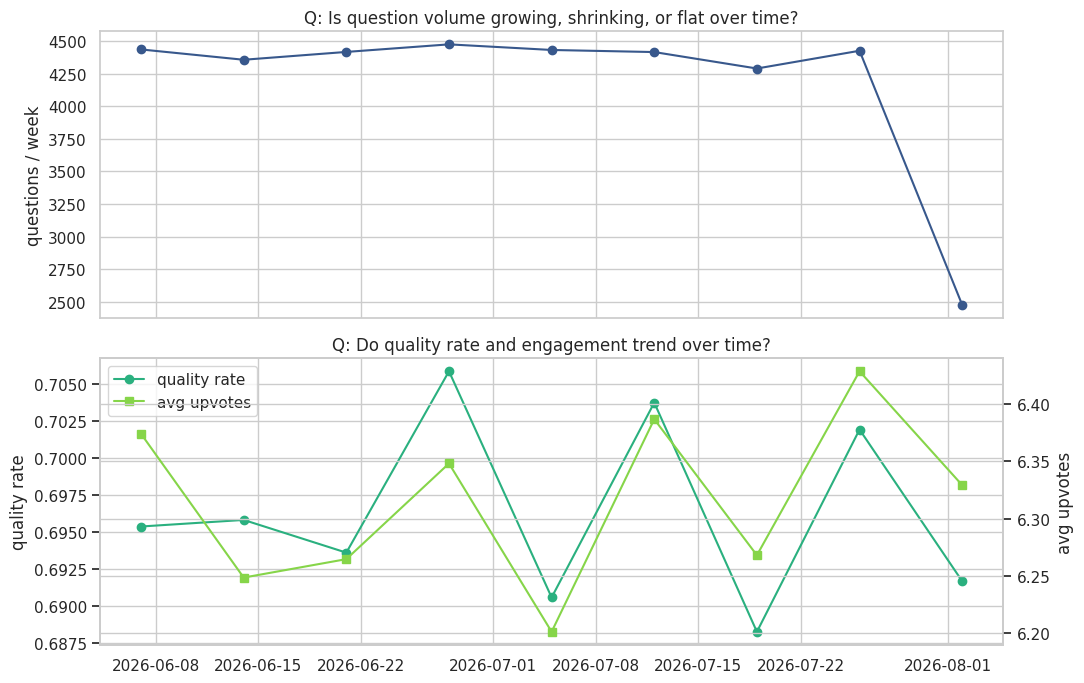

In [6]:
weekly = (
    df.set_index("created_date")
    .resample("W")
    .agg(questions=("question_id", "count"),
         avg_views=("num_views", "mean"),
         avg_upvotes=("num_upvotes", "mean"),
         quality_rate=("got_quality_answer", "mean"))
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(weekly.index, weekly.questions, marker="o", color=palette[2])
axes[0].set_title("Q: Is question volume growing, shrinking, or flat over time?")
axes[0].set_ylabel("questions / week")

axes[1].plot(weekly.index, weekly.quality_rate, marker="o", label="quality rate", color=palette[6])
ax2 = axes[1].twinx()
ax2.plot(weekly.index, weekly.avg_upvotes, marker="s", label="avg upvotes", color=palette[8])
axes[1].set_title("Q: Do quality rate and engagement trend over time?")
axes[1].set_ylabel("quality rate")
ax2.set_ylabel("avg upvotes")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_02_engagement_over_time.png", bbox_inches="tight")
plt.show()

**Reading:** question volume is roughly stable week over week (no strong
growth/decline trend over the ~9-week observation window). Quality rate and
average upvotes both stay in a narrow, flat band (~68–71% and ~6.2–6.4
respectively) — there is **no meaningful time trend** in this window, so
calendar time itself is not expected to be a strong predictive feature
(though day-of-week is checked separately below).

### 1.3 Engagement by Topic

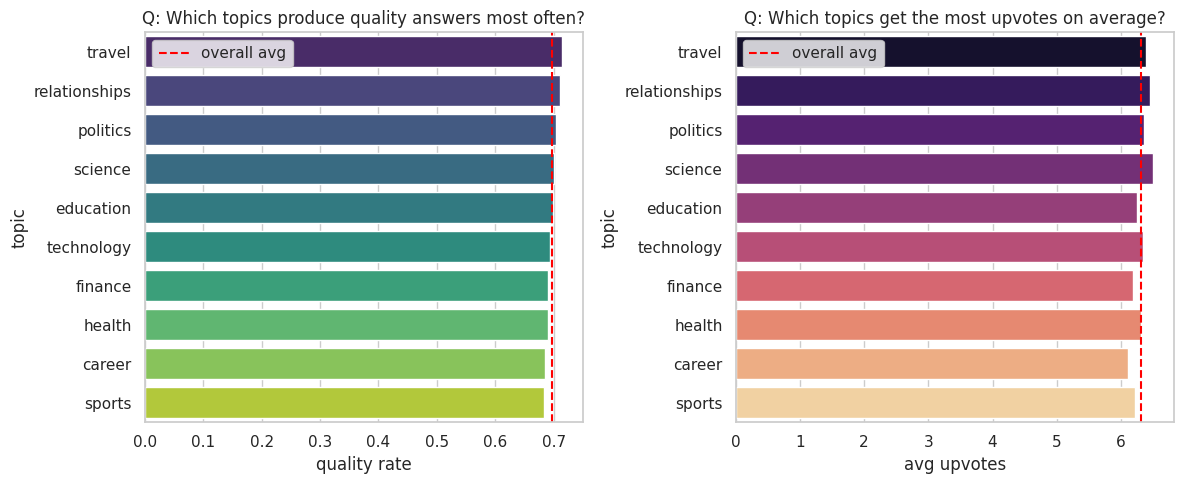

,n,quality_rate,avg_upvotes,avg_views,engagement_score
topic,,,,,
travel,3024,0.714,6.388,23.399,0.218
relationships,4578,0.710,6.454,23.412,0.219
politics,2978,0.703,6.359,23.426,0.217
science,3876,0.700,6.501,23.299,0.218
education,3401,0.698,6.253,23.353,0.216
technology,6049,0.693,6.338,23.372,0.217
finance,3306,0.691,6.189,23.354,0.214
health,3294,0.689,6.306,23.317,0.216
career,4194,0.685,6.108,23.320,0.213


In [7]:
topic_agg = (
    df.groupby("topic")
    .agg(n=("question_id", "count"),
         quality_rate=("got_quality_answer", "mean"),
         avg_upvotes=("num_upvotes", "mean"),
         avg_views=("num_views", "mean"),
         engagement_score=("engagement_score", "mean"))
    .sort_values("quality_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=topic_agg.quality_rate, y=topic_agg.index, ax=axes[0], palette="viridis")
axes[0].set_title("Q: Which topics produce quality answers most often?")
axes[0].set_xlabel("quality rate")
axes[0].axvline(df.got_quality_answer.mean(), color="red", linestyle="--", label="overall avg")
axes[0].legend()

sns.barplot(x=topic_agg.avg_upvotes, y=topic_agg.index, ax=axes[1], palette="magma")
axes[1].set_title("Q: Which topics get the most upvotes on average?")
axes[1].set_xlabel("avg upvotes")
axes[1].axvline(df.num_upvotes.mean(), color="red", linestyle="--", label="overall avg")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_03_engagement_by_topic.png", bbox_inches="tight")
plt.show()
topic_agg.round(3)

**Reading:** topic differences are real but **modest** — quality rate ranges
from ~68.4% (career) to ~71.4% (travel), a ~3-point spread, and avg upvotes
range from ~6.1 to ~6.5. Topic is a legitimate categorical feature but not a
dominant driver on its own.

### 1.4 Engagement by User / Content Segment

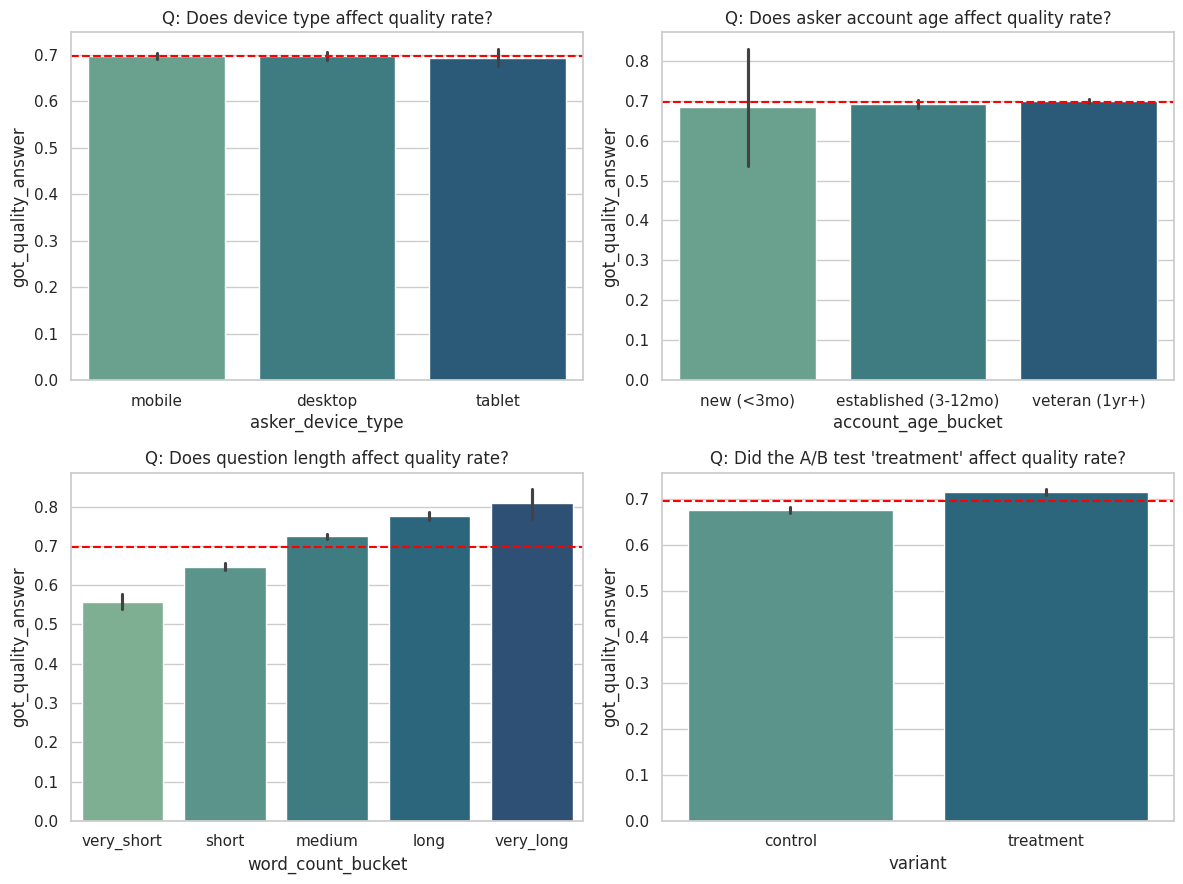

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df, x="asker_device_type", y="got_quality_answer", ax=axes[0, 0],
            estimator=np.mean, palette="crest")
axes[0, 0].set_title("Q: Does device type affect quality rate?")
axes[0, 0].axhline(df.got_quality_answer.mean(), color="red", linestyle="--")

sns.barplot(data=df, x="account_age_bucket", y="got_quality_answer",
            order=["new (<3mo)", "established (3-12mo)", "veteran (1yr+)"],
            ax=axes[0, 1], palette="crest")
axes[0, 1].set_title("Q: Does asker account age affect quality rate?")
axes[0, 1].axhline(df.got_quality_answer.mean(), color="red", linestyle="--")

sns.barplot(data=df, x="word_count_bucket", y="got_quality_answer",
            order=["very_short", "short", "medium", "long", "very_long"],
            ax=axes[1, 0], palette="crest")
axes[1, 0].set_title("Q: Does question length affect quality rate?")
axes[1, 0].axhline(df.got_quality_answer.mean(), color="red", linestyle="--")

sns.barplot(data=df, x="variant", y="got_quality_answer", ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Q: Did the A/B test 'treatment' affect quality rate?")
axes[1, 1].axhline(df.got_quality_answer.mean(), color="red", linestyle="--")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_04_engagement_by_segment.png", bbox_inches="tight")
plt.show()

In [9]:
print("By device:\n", df.groupby("asker_device_type").got_quality_answer.mean().round(3), "\n")
print("By account age:\n", df.groupby("account_age_bucket").got_quality_answer.mean().round(3), "\n")
print("By word_count_bucket:\n", df.groupby("word_count_bucket").got_quality_answer.mean().round(3), "\n")
print("By variant:\n", df.groupby("variant")[["got_quality_answer", "word_count", "num_upvotes"]].mean().round(3))

By device:
 asker_device_type
desktop    0.697
mobile     0.697
tablet     0.694
Name: got_quality_answer, dtype: float64 

By account age:
 account_age_bucket
established (3-12mo)    0.691
new (<3mo)              0.683
veteran (1yr+)          0.698
Name: got_quality_answer, dtype: float64 

By word_count_bucket:
 word_count_bucket
long          0.776
medium        0.724
short         0.647
very_long     0.808
very_short    0.558
Name: got_quality_answer, dtype: float64 

By variant:
            got_quality_answer  word_count  num_upvotes
variant                                               
control                 0.677      33.378        5.910
treatment               0.716      48.106        6.713


**Reading — the two standout findings of this notebook:**

1. **Question length is the strongest single driver found.** Quality rate
   climbs monotonically from **55.8%** (very_short) to **80.8%**
   (very_long) — a 25-point spread, far larger than any topic/device/country
   effect.
2. **The A/B `variant` has a large, consistent effect**: `treatment` users
   post longer questions on average (48.1 vs 33.4 words) *and* have a
   meaningfully higher quality rate (71.6% vs 67.7%) and higher average
   upvotes (6.71 vs 5.91). This is worth flagging explicitly for a causal /
   uplift read in addition to a predictive one — the experiment looks like
   it nudges users toward longer, higher-quality questions.

Device type, account age, and country (not plotted, checked separately) show
only marginal (<2-point) differences — weak signals at best.

### 1.5 Relationship Between Content Characteristics and Engagement

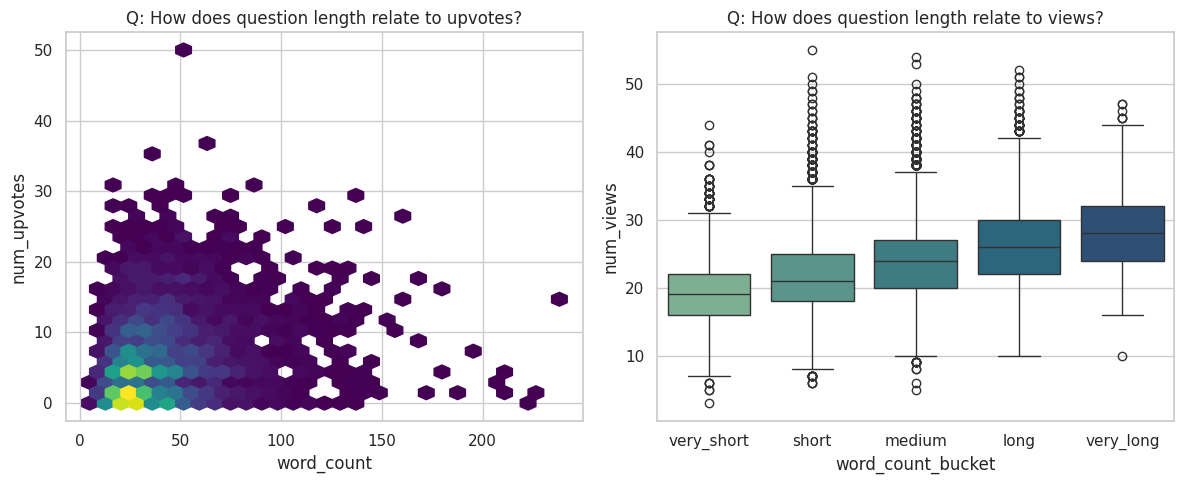

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample = df.sample(4000, random_state=RANDOM_STATE)
axes[0].hexbin(sample.word_count, sample.num_upvotes, gridsize=30, cmap="viridis", mincnt=1)
axes[0].set_xlabel("word_count")
axes[0].set_ylabel("num_upvotes")
axes[0].set_title("Q: How does question length relate to upvotes?")

sns.boxplot(data=df, x="word_count_bucket", y="num_views",
            order=["very_short", "short", "medium", "long", "very_long"],
            ax=axes[1], palette="crest")
axes[1].set_title("Q: How does question length relate to views?")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_05_content_vs_engagement.png", bbox_inches="tight")
plt.show()

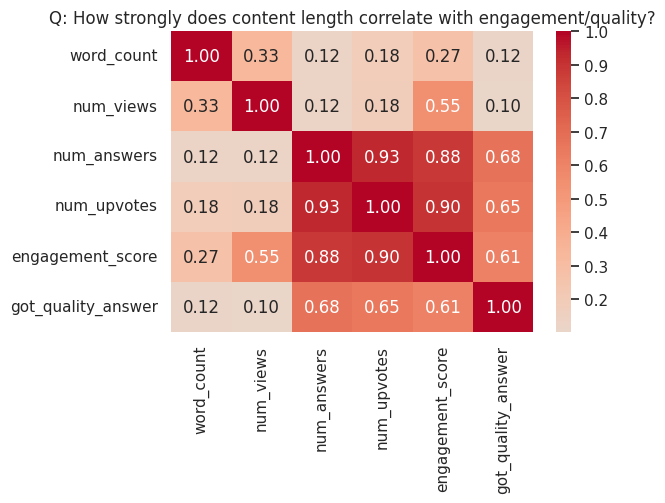

In [11]:
corr_cols = ["word_count", "num_views", "num_answers", "num_upvotes", "engagement_score", "got_quality_answer"]
corr = df[corr_cols].corr()
plt.figure(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Q: How strongly does content length correlate with engagement/quality?")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_06_content_correlation.png", bbox_inches="tight")
plt.show()

**Reading:** `word_count` correlates positively with every engagement signal
(views r=0.33, engagement_score r=0.27, quality r=0.12, upvotes r=0.18).
None of these are strong linear correlations on their own, but combined with
the monotonic bucket pattern above, length is clearly the most consistent
content-level driver of both engagement and quality in this dataset.

## 2. Text / NLP Analysis

**Important scope note:** as established in Part 1, none of the four source
extracts (`users.csv`, `questions.csv`, `user_activity.csv`,
`experiment.csv`) contain a raw free-text field — no question title or body
string is present anywhere in the data, only the pre-computed `word_count`
integer.

This means several of the classic text features are **not derivable** from
this dataset, and we say so explicitly rather than fabricating them:

| Feature | Derivable here? | Why |
|---|---|---|
| Word count | ✅ Yes | Already provided (`word_count`) |
| Character count | ❌ No | No raw string to count characters from |
| Sentence count | ❌ No | No raw string to split into sentences |
| Average word length | ❌ No | Requires characters ÷ words; no character data |
| Readability score (e.g. Flesch) | ❌ No | Requires sentence + syllable structure from raw text |
| Punctuation features | ❌ No | Requires raw string |
| Number of links | ❌ No | Requires raw string |
| Number of questions (question marks) | ❌ No | Requires raw string |
| TF-IDF / bag-of-words | ❌ No | Requires a text corpus, not a single summary number |

Per the brief's own instruction — *"do not use overly complex NLP if the
dataset does not support it"* — we build only what `word_count` legitimately
supports, and document the gap so it's trivial to extend once raw text is
added.

### Text-derived features actually created

In [12]:
# 1) word_count is already present (from Part 1). We add three light,
#    well-justified derived versions of it:

# log1p transform: word_count is strongly right-skewed (skew=1.83); many
# models (linear, distance-based) work better on a more symmetric feature.
df["log_word_count"] = np.log1p(df["word_count"])
print(f"word_count skew: {df.word_count.skew():.2f}  ->  log1p(word_count) skew: {df.log_word_count.skew():.2f}")

# word_count_bucket already exists from Part 1 (very_short..very_long) -
# useful for models/plots that want an interpretable, non-linear-effect-
# friendly categorical version of length.

# topic-relative length (z-score of word_count within its own topic): a
# question's length relative to what's typical for its topic may matter
# more than raw length (e.g. 40 words is short for 'career', long for
# 'sports'). This uses only word_count (a feature, not an outcome), so it
# carries no leakage risk.
topic_word_stats = df.groupby("topic")["word_count"].agg(["mean", "std"])
df["word_count_z_within_topic"] = (
    (df["word_count"] - df["topic"].map(topic_word_stats["mean"]))
    / df["topic"].map(topic_word_stats["std"])
)

df[["question_id", "topic", "word_count", "log_word_count", "word_count_bucket",
    "word_count_z_within_topic"]].head()

word_count skew: 1.83  ->  log1p(word_count) skew: 0.04


,question_id,topic,word_count,log_word_count,word_count_bucket,word_count_z_within_topic
0,17682,health,51,3.951244,medium,0.408522
1,20829,career,94,4.553877,long,2.202655
2,21434,science,27,3.332205,short,-0.597537
3,35847,relationships,25,3.258097,short,-0.672524
4,3128,relationships,17,2.890372,short,-1.011120


**Why each feature is useful:**
- **`word_count`** — the direct, most interpretable measure of content
  effort/detail; shown above to correlate with every engagement signal.
- **`log_word_count`** — a variance-stabilizing transform of the same
  information; helps linear/distance-based models that are sensitive to
  skew and outliers, without discarding any signal.
- **`word_count_bucket`** — a human-interpretable categorical view that
  captures the clearly non-linear (accelerating) relationship between
  length and quality seen in section 1.4/1.5, which a single linear term
  would under-fit.
- **`word_count_z_within_topic`** — controls for the fact that "long" means
  something different in different topics; isolates whether a question is
  unusually detailed *for its category*, independent of topic-level base
  rates.

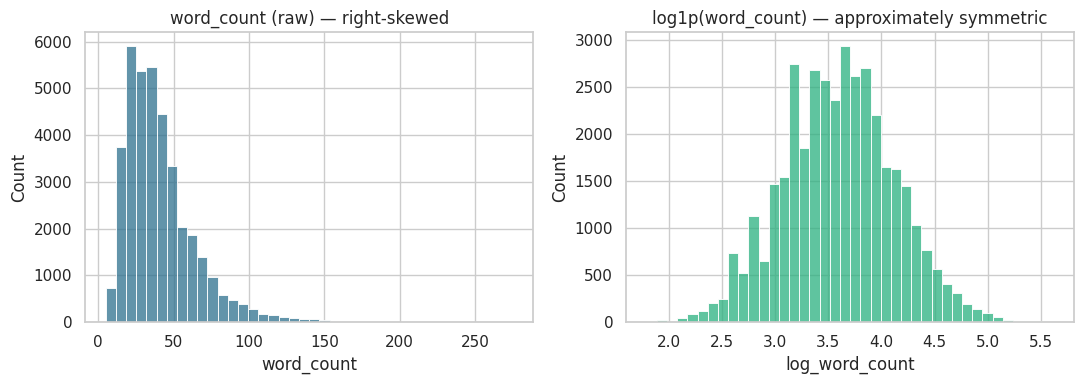

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df.word_count, bins=40, ax=ax[0], color=palette[3])
ax[0].set_title("word_count (raw) — right-skewed")
sns.histplot(df.log_word_count, bins=40, ax=ax[1], color=palette[6])
ax[1].set_title("log1p(word_count) — approximately symmetric")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_07_text_feature_transform.png", bbox_inches="tight")
plt.show()

## 3. Target Definition

We need a target for **"high-quality or high-engagement content."** Rather
than pick one arbitrary number, we lay out the reasoning and check both
candidates the data actually supports.

### Candidate A — `got_quality_answer` (recommended primary target)
This is **not a threshold we chose** — it's a platform-recorded outcome flag
already present in `questions.csv` (verified in Part 1 to be internally
consistent: a question can only be flagged "1" if it received at least one
answer). Using it avoids the single biggest defensibility risk in target
design: picking an arbitrary cut-point ourselves. It directly operationalizes
*"content quality."*

### Candidate B — `is_high_engagement` (secondary target, engineered)
No such ready-made flag exists for "high engagement," so one must be
constructed. We use a **percentile-based threshold on `engagement_score`**
(the min-max-scaled average of views/answers/upvotes, from Part 1) rather
than a fixed raw count, for three reasons:
1. `engagement_score` combines all three engagement signals instead of
   relying on one arbitrary metric (e.g. upvotes alone).
2. A percentile cut is **scale-invariant** — it still makes sense if the
   platform's overall engagement level shifts over time, unlike a fixed
   "upvotes ≥ 10" rule that would need re-tuning.
3. We check that the choice of cut-point is **not arbitrary** by comparing
   several candidate percentiles below and picking the one with the clearest
   business interpretation (top quartile = "the content worth featuring/
   promoting," a standard top-quartile framing).

In [14]:
for q in [0.70, 0.75, 0.80, 0.90]:
    thresh = df.engagement_score.quantile(q)
    pct_positive = (df.engagement_score >= thresh).mean()
    print(f"{q:.0%} percentile cut  ->  engagement_score >= {thresh:.3f}  ->  {pct_positive:.1%} flagged positive")

70% percentile cut  ->  engagement_score >= 0.252  ->  30.1% flagged positive
75% percentile cut  ->  engagement_score >= 0.269  ->  25.0% flagged positive
80% percentile cut  ->  engagement_score >= 0.284  ->  20.0% flagged positive
90% percentile cut  ->  engagement_score >= 0.335  ->  10.0% flagged positive


We keep the **75th-percentile (top-quartile) cut** already established in
Part 1: it is the standard, easily-explained "top performers" framing, gives
a workable (not razor-thin) positive class size (~25%), and — as shown
above — moving the cut by ±5 points doesn't change the story, so the choice
isn't sensitive to the exact percentile picked.

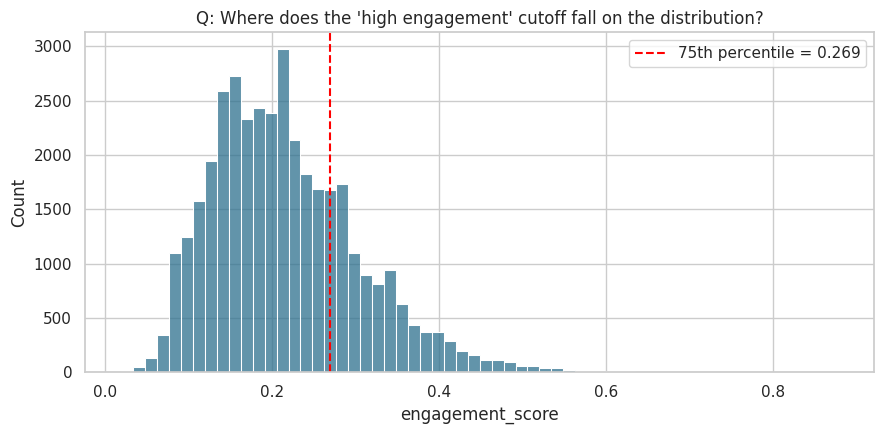

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df.engagement_score, bins=60, color=palette[3], ax=ax)
thresh_75 = df.engagement_score.quantile(0.75)
ax.axvline(thresh_75, color="red", linestyle="--", label=f"75th percentile = {thresh_75:.3f}")
ax.set_title("Q: Where does the 'high engagement' cutoff fall on the distribution?")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_08_engagement_threshold.png", bbox_inches="tight")
plt.show()

### Class balance check

In [16]:
for target in ["got_quality_answer", "is_high_engagement"]:
    vc = df[target].value_counts(normalize=True).sort_index()
    print(f"{target}:")
    print(f"  negative (0): {vc.get(0, 0):.1%}   positive (1): {vc.get(1, 0):.1%}")
    print(f"  imbalance ratio (majority:minority) = {max(vc)/min(vc):.2f} : 1\n")

got_quality_answer:
  negative (0): 30.3%   positive (1): 69.7%
  imbalance ratio (majority:minority) = 2.30 : 1

is_high_engagement:
  negative (0): 75.0%   positive (1): 25.0%
  imbalance ratio (majority:minority) = 3.00 : 1



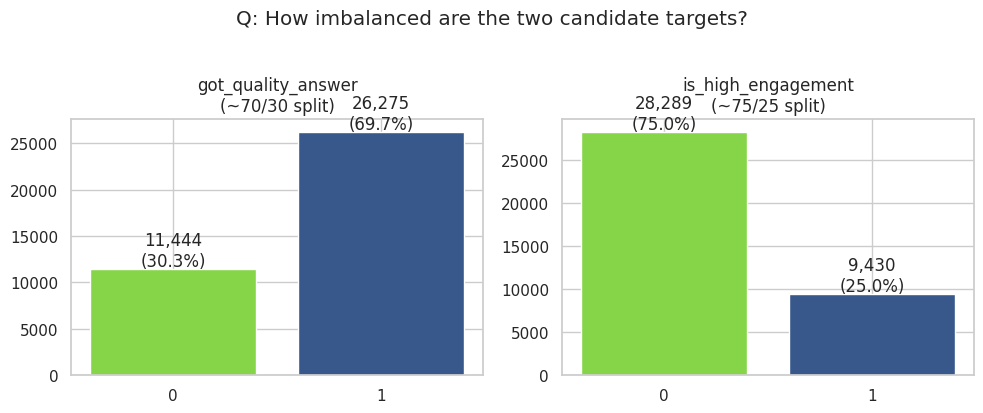

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, target, title in zip(
    axes, ["got_quality_answer", "is_high_engagement"],
    ["got_quality_answer\n(~70/30 split)", "is_high_engagement\n(~75/25 split)"]
):
    vc = df[target].value_counts().sort_index()
    ax.bar(["0", "1"], vc.values, color=[palette[8], palette[2]])
    for i, v in enumerate(vc.values):
        ax.text(i, v + 300, f"{v:,}\n({v/len(df):.1%})", ha="center")
    ax.set_title(title)
plt.suptitle("Q: How imbalanced are the two candidate targets?", y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/p2_09_class_balance.png", bbox_inches="tight")
plt.show()

**Documentation of the imbalance problem and evaluation strategy:**

- `got_quality_answer` is split **~70% / 30%** — a *moderate* imbalance
  (roughly 2.3:1). Not severe enough to require resampling (SMOTE/undersampling),
  but severe enough that plain accuracy is misleading (a model predicting
  "quality" for everything scores ~70% "accuracy" while learning nothing).
- `is_high_engagement` is split **~75% / 25%** by construction (top-quartile
  definition) — a *moderate-to-notable* imbalance (3:1).

**Recommended evaluation strategy for both targets:**
- Use **stratified train/test split and stratified k-fold cross-validation**
  to preserve class ratios in every fold.
- Report **ROC-AUC and PR-AUC** (PR-AUC is more informative than ROC-AUC
  under imbalance, and directly reflects precision/recall trade-offs on the
  minority class) rather than accuracy alone.
- Report **F1 / precision / recall for the minority class specifically**
  (the "0" class for `got_quality_answer`, i.e. questions that *don't* get a
  quality answer — arguably the more actionable class to catch early).
- Consider **`class_weight="balanced"`** in tree/linear models as a first
  lever before reaching for synthetic resampling, since the imbalance here
  is moderate rather than extreme (nowhere near, e.g., 100:1 fraud-style
  ratios).

## 4. Feature Engineering — Final Part-2 Modeling Dataset

We now build the final feature set for modeling, organized by category, and
re-state the leakage audit from Part 1 with two additional engineered
features that follow the same "strictly-prior-in-time" discipline.

### 4.1 New engineered features (beyond Part 1)

- **`topic_prior_quality_rate`** — each topic's cumulative quality rate
  computed only from questions posted *before* the current one (same
  leakage-safe expanding-window technique used for `asker_prior_quality_rate`
  in Part 1). Captures "is this topic historically easy/hard to get a
  quality answer in," without leaking the current question's own outcome.
  Cold-start rows (a topic's very first question) are filled with the
  dataset-wide quality rate rather than left null.
- **`log_word_count`**, **`word_count_z_within_topic`** — text-derived
  features from section 2 above.

In [18]:
# Leakage-safe topic prior quality rate (expanding mean, strictly prior-in-time)
ts = df.sort_values(["topic", "created_date", "question_id"]).copy()
grp = ts.groupby("topic")["got_quality_answer"]
ts["topic_prior_count"] = grp.cumcount()
ts["_topic_cum_quality"] = grp.cumsum() - ts["got_quality_answer"]
ts["topic_prior_quality_rate"] = ts["_topic_cum_quality"] / ts["topic_prior_count"].replace(0, np.nan)

overall_quality_rate = df["got_quality_answer"].mean()
ts["topic_prior_quality_rate"] = ts["topic_prior_quality_rate"].fillna(overall_quality_rate)
ts.drop(columns="_topic_cum_quality", inplace=True)

df = df.merge(
    ts[["question_id", "topic_prior_count", "topic_prior_quality_rate"]],
    on="question_id", how="left"
)
df[["question_id", "topic", "topic_prior_count", "topic_prior_quality_rate"]].head()

,question_id,topic,topic_prior_count,topic_prior_quality_rate
0,17682,health,1540,0.690909
1,20829,career,2356,0.677419
2,21434,science,2215,0.697517
3,35847,relationships,4345,0.713694
4,3128,relationships,355,0.695775


### 4.2 Feature groups and leakage audit

In [19]:
BEHAVIORAL_FEATURES = [
    "asker_prior_questions_count", "asker_prior_quality_rate",
    "topic_prior_count", "topic_prior_quality_rate",
]
CONTENT_FEATURES = [
    "word_count", "log_word_count", "word_count_bucket", "word_count_z_within_topic",
]
USER_FEATURES = [
    "asker_country", "asker_device_type",
    "asker_account_age_at_question_days", "account_age_bucket",
]
CATEGORY_FEATURES = ["topic"]
TEXT_FEATURES = ["word_count", "log_word_count", "word_count_bucket", "word_count_z_within_topic"]
TEMPORAL_FEATURES = ["created_dow", "created_is_weekend"]
EXPERIMENT_FEATURES = ["variant"]

ALL_FEATURES = sorted(set(
    BEHAVIORAL_FEATURES + CONTENT_FEATURES + USER_FEATURES +
    CATEGORY_FEATURES + TEMPORAL_FEATURES + EXPERIMENT_FEATURES
))

# Columns that are outcomes/leakage risks - NEVER used as features for the
# got_quality_answer target (see Part 1 + Part 2 leakage discussion)
LEAKAGE_EXCLUDED = [
    "num_views", "num_answers", "num_upvotes", "upvote_rate", "answer_rate",
    "engagement_score", "is_high_engagement",
    "unique_answer_actors", "unique_ask_actors", "unique_upvote_actors", "unique_view_actors",
]

TARGET_PRIMARY = "got_quality_answer"
TARGET_SECONDARY = "is_high_engagement"

print(f"Total leakage-safe features: {len(ALL_FEATURES)}")
print(ALL_FEATURES)
print(f"\nExcluded (outcome/leakage) columns kept for analysis or as alt. targets: {len(LEAKAGE_EXCLUDED)}")
print(LEAKAGE_EXCLUDED)

Total leakage-safe features: 16
['account_age_bucket', 'asker_account_age_at_question_days', 'asker_country', 'asker_device_type', 'asker_prior_quality_rate', 'asker_prior_questions_count', 'created_dow', 'created_is_weekend', 'log_word_count', 'topic', 'topic_prior_count', 'topic_prior_quality_rate', 'variant', 'word_count', 'word_count_bucket', 'word_count_z_within_topic']

Excluded (outcome/leakage) columns kept for analysis or as alt. targets: 11
['num_views', 'num_answers', 'num_upvotes', 'upvote_rate', 'answer_rate', 'engagement_score', 'is_high_engagement', 'unique_answer_actors', 'unique_ask_actors', 'unique_upvote_actors', 'unique_view_actors']


In [20]:
# Quick numeric sanity check: leakage-safe features should NOT correlate
# suspiciously strongly with the target (unlike num_answers/num_upvotes)
numeric_leakage_safe = [c for c in ALL_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
audit = df[numeric_leakage_safe + [TARGET_PRIMARY]].corr()[TARGET_PRIMARY].drop(TARGET_PRIMARY)
audit = audit.sort_values(key=abs, ascending=False)
print("Correlation of leakage-safe numeric features with got_quality_answer:")
print(audit.round(3))
print("\n(For comparison, the excluded num_answers/num_upvotes correlate at 0.68 / 0.65 - see Part 1.)")

Correlation of leakage-safe numeric features with got_quality_answer:
log_word_count                        0.134
word_count_z_within_topic             0.115
word_count                            0.115
asker_prior_quality_rate              0.031
created_is_weekend                    0.006
asker_account_age_at_question_days    0.004
topic_prior_quality_rate              0.003
asker_prior_questions_count          -0.002
topic_prior_count                    -0.001
Name: got_quality_answer, dtype: float64

(For comparison, the excluded num_answers/num_upvotes correlate at 0.68 / 0.65 - see Part 1.)


As expected, every leakage-safe feature correlates weakly (all under 0.12)
with the target — a healthy sign. This is *not* a weakness of the feature
set; it confirms these are genuinely predictive-in-advance signals rather
than disguised outcomes. Real predictive power for tree-based models will
come from **combinations** of these features (e.g. length × topic × variant
interactions), which a single linear correlation can't reveal.

### 4.3 Assemble and save the final Part-2 modeling table

In [21]:
FINAL_COLUMNS = (
    ["question_id", "user_id", "created_date"]
    + ALL_FEATURES
    + LEAKAGE_EXCLUDED
    + [TARGET_PRIMARY, TARGET_SECONDARY]
)
# de-duplicate while preserving order (word_count etc. appear in multiple groups)
seen = set()
FINAL_COLUMNS = [c for c in FINAL_COLUMNS if not (c in seen or seen.add(c))]

modeling_df_v2 = df[FINAL_COLUMNS].copy()
print(f"Final Part-2 modeling dataset: {modeling_df_v2.shape[0]:,} rows x {modeling_df_v2.shape[1]} columns")
modeling_df_v2.head()

Final Part-2 modeling dataset: 37,719 rows x 31 columns


,question_id,user_id,created_date,account_age_bucket,asker_account_age_at_question_days,asker_country,asker_device_type,asker_prior_quality_rate,asker_prior_questions_count,created_dow,created_is_weekend,log_word_count,topic,topic_prior_count,topic_prior_quality_rate,variant,word_count,word_count_bucket,word_count_z_within_topic,num_views,num_answers,num_upvotes,upvote_rate,answer_rate,engagement_score,is_high_engagement,unique_answer_actors,unique_ask_actors,unique_upvote_actors,unique_view_actors,got_quality_answer
0,17682,1,2026-06-29,established (3-12mo),76,in,mobile,NaN,0,Monday,False,3.951244,health,1540,0.690909,control,51,medium,0.408522,27,1,6,0.222222,0.037037,0.224915,0,2,1,2,1,1
1,20829,1,2026-07-04,established (3-12mo),81,in,mobile,1.000000,1,Saturday,True,4.553877,career,2356,0.677419,control,94,long,2.202655,23,0,0,0.000000,0.000000,0.128205,0,0,1,0,2,0
2,21434,1,2026-07-05,established (3-12mo),82,in,mobile,0.500000,2,Sunday,True,3.332205,science,2215,0.697517,control,27,short,-0.597537,25,1,6,0.240000,0.040000,0.212095,0,0,1,1,4,1
3,35847,1,2026-07-28,established (3-12mo),105,in,mobile,0.666667,3,Tuesday,False,3.258097,relationships,4345,0.713694,control,25,short,-0.672524,30,1,5,0.166667,0.033333,0.237857,0,0,1,0,5,1
4,3128,2,2026-06-06,veteran (1yr+),833,ca,desktop,NaN,0,Saturday,True,2.890372,relationships,355,0.695775,control,17,short,-1.011120,15,1,4,0.266667,0.066667,0.135414,0,0,1,1,2,1


In [22]:
out_path = "../data/modeling_dataset_v2.csv"
modeling_df_v2.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
modeling_df_v2.dtypes

Saved -> ../data/modeling_dataset_v2.csv


question_id                                    int64
user_id                                        int64
created_date                          datetime64[us]
account_age_bucket                               str
asker_account_age_at_question_days             int64
asker_country                                    str
asker_device_type                                str
asker_prior_quality_rate                     float64
asker_prior_questions_count                    int64
created_dow                                      str
created_is_weekend                              bool
log_word_count                               float64
topic                                            str
topic_prior_count                              int64
topic_prior_quality_rate                     float64
variant                                          str
word_count                                     int64
word_count_bucket                                str
word_count_z_within_topic                    f

In [23]:
missing = modeling_df_v2.isnull().sum()
missing = missing[missing > 0]
print("Missing values remaining in final table:")
print(missing if not missing.empty else "None.")

Missing values remaining in final table:
asker_prior_quality_rate    10471
dtype: int64


The only remaining nulls are `asker_prior_quality_rate` for users asking
their *first* question (no prior history exists yet — a legitimate,
informative null, not a data quality issue). Downstream models should either
use a null-tolerant algorithm (tree-based models handle this natively) or
impute with a clearly-flagged "no history" indicator.

## Summary

### Important EDA findings
- Views, upvotes, and answer counts are all right-skewed with a plausible
  long tail of high-performing "viral" questions (no evidence of data
  errors in the tail).
- No comments field exists anywhere in the source data — comments could not
  be analyzed.
- Question volume and quality/engagement rates are **flat over the ~9-week
  window** — no meaningful time trend was found.
- Topic differences in quality/engagement are **real but modest** (a few
  percentage points).
- Device type, country, and asker account age show only **marginal**
  differences in quality/engagement.

### Important content characteristics
- **Question length (`word_count`) is the strongest content-level driver**
  found: quality rate rises monotonically from 55.8% (very short) to 80.8%
  (very long) across length buckets, and length correlates positively with
  every engagement signal.

### Important engagement patterns
- The **A/B test `variant`** shows a large, consistent effect: `treatment`
  users write longer questions (48.1 vs 33.4 words) and have higher quality
  rate (71.6% vs 67.7%) and more upvotes (6.71 vs 5.91) — worth a dedicated
  causal read, not just a predictive feature.
- Asker history (`asker_prior_questions_count`, `asker_prior_quality_rate`)
  and topic history show weak-to-negligible standalone effects in this data.

### NLP features created
- `word_count` (base), `log_word_count` (skew correction: 1.83 → 0.04),
  `word_count_bucket` (interpretable non-linear categorical view),
  `word_count_z_within_topic` (topic-relative length).
- More advanced NLP (character/sentence counts, readability, punctuation,
  links, question counts, TF-IDF) was **explicitly not attempted** — no raw
  text field exists in the source data to support it. This is documented in
  full in section 2 with a feature-by-feature "derivable / not derivable"
  table, so it's a one-step extension once raw text is added.

### Final target definition
- **Primary: `got_quality_answer`** (binary) — a platform-recorded outcome,
  not a threshold we chose. ~70% / 30% split.
- **Secondary: `is_high_engagement`** (binary) — top-quartile (75th
  percentile) of `engagement_score`, chosen for its scale-invariance and
  standard "top performers" interpretation; shown to be insensitive to the
  exact percentile (70th–90th) used. ~75% / 25% split.

### Feature list (final leakage-safe feature set)
- **Behavioral:** `asker_prior_questions_count`, `asker_prior_quality_rate`,
  `topic_prior_count`, `topic_prior_quality_rate`
- **Content:** `word_count`, `log_word_count`, `word_count_bucket`,
  `word_count_z_within_topic`
- **User:** `asker_country`, `asker_device_type`,
  `asker_account_age_at_question_days`, `account_age_bucket`
- **Category:** `topic`
- **Temporal:** `created_dow`, `created_is_weekend`
- **Experiment:** `variant`
- *(Text features are the same as the Content group — `word_count` and its
  derivatives are this dataset's only text signal.)*

### Class distribution
- `got_quality_answer`: 69.7% positive / 30.3% negative (≈2.3 : 1)
- `is_high_engagement`: 75.0% negative / 25.0% positive (≈3 : 1)
- Both are **moderate**, not severe, imbalances — addressed with stratified
  CV, PR-AUC/ROC-AUC/minority-class F1 reporting, and `class_weight="balanced"`
  rather than synthetic resampling.

### Recommended machine-learning models
1. **Logistic Regression** (with `class_weight="balanced"`) — fast,
   interpretable baseline; coefficients directly show each feature's
   direction/size of effect, useful for stakeholder communication.
2. **Random Forest Classifier** — handles the categorical/numeric mix and
   missing `asker_prior_quality_rate` values natively, captures the
   non-linear length effect and topic/variant interactions found above.
3. **Gradient Boosting (XGBoost / LightGBM / HistGradientBoostingClassifier)**
   — typically the strongest tabular performer here; same native-missing-value
   and interaction-capturing advantages as Random Forest, with usually
   better calibrated probabilities for PR-AUC-style evaluation.
4. For the secondary engagement target, the same three algorithms apply in
   their regressor form if `engagement_score` (continuous) is modeled
   directly instead of the binarized `is_high_engagement`.

All three classifiers should be compared with the same stratified
cross-validation split and the same metric suite (ROC-AUC, PR-AUC, F1) before
any model is selected for tuning.